# Machine Learning Assignment 1



---


## Author : Joel Quadras (D22125093)
## Experiment comparing data splitting techniques K-Fold Cross Validation and Hold-out Validation.


# Introduction

Machine learning models have revolutionized the way we process and analyze data. In order to measure the performance of these predictive models, data-splitting methodologies play a crucial role. The holdout testing method is the most commonly used approach, where the dataset is divided into two sets: a training set and a test set. However, this method can lead to variations in model performance estimates, especially for smaller datasets. 

K-fold cross-validation is a more robust data-splitting methodology that provides better and more reliable estimates of model performance, especially for smaller datasets. In this method, the dataset is divided into K subsets or folds. Each fold is used as a test set, while the remaining K-1 folds are used as training sets. This process is repeated K times, with each fold being used as a test set once. The results are then averaged to obtain a final estimate of model performance.

This experiment aims to compare the holdout and K-fold cross-validation methods using the multiple datasets from the UCI repository. The goal is to determine which method provides a more accurate and robust estimate of model performance. To ensure unbiased results, various machine learning algorithms such as KNN, Naive Bayes, Decision tree, and SVM will be evaluated using both methods.

The final aim of this experiment is to prove that for smaller datasets where the sample size is lesser than 500, K-fold cross-validation is the more optimal and reliable data splitting approach as compared to holdout. The results of this experiment will help data scientists and machine learning practitioners to choose the best data-splitting methodology based on the size of their dataset and other relevant factors. In conclusion, data-splitting methodologies play a crucial role in measuring the performance of predictive machine learning models, and K-fold cross-validation is a more robust method that can provide better and more reliable estimates of model performance, especially for smaller datasets.



## Importing Libraries
Let's start by importing all the essential libraries that we need for this experiment! We're bringing in libraries from the ever-popular sklearn toolkit to build and run a plethora of models. To further enhance our data visualization game, we're also importing Plotly and Seaborn to create stunning graphs that will captivate your attention. Of course, we can't forget about the indispensable libraries such as Pandas and Numpy, which will help us manipulate and wrangle our data with ease.

In [1]:
## Install required modules
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy sklearn pandas numpy

# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
import seaborn as sns
from copy import deepcopy
from pprint import PrettyPrinter


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [8 lines of output]
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\joelq\AppData\Local\Temp\pip-install-jh_4pj0e\sklearn_244c16840888479bb09f565c21d2ba13\setup.py", line 10, in <module>
      LONG_DESCRIPTION = f.read()
    File "C:\Users\joelq\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 23, in decode
      return codecs.charmap_decode(input,self.errors,decoding_table)[0]
  UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 7: character maps to <undefined>
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

Encountered error while generating package metadata.

See above for output.

note: This is an issue with the package mentioned a

## Experiment 

### Wine Dataset 
The wine dataset is a classic machine-learning dataset widely used in the research community. It was developed by Forina et al. in 1990, it is widely used as a benchmark dataset for classification and regression tasks.

The dataset contains data for three types of wine.The first variety is called 'Barolo', the second 'Grignolino' and the third 'Barbera'. There are 59 samples of Barolo wines, 71 samples of Grignolino wines and 48 samples of Barbera wines for a total of 178 samples. Thirteen different attributes were measured for each wine sample. These attributes are considered important in determining the quality and character of a particular wine. The 13 attributes are:
1. Alcohol
2. Malic acid
3. Ash
4. Alcalinity of ash
5. Magnesium
6. Total phenols
7. Flavanoids
8. Nonflavanoid phenols
9. Proanthocyanins
10. Color intensity
11. Hue
12. OD280/OD315 of diluted wines
13. Proline

The first attribute, alcohol, is the percentage of alcohol in the wine. Malic acid, ash and ash alkalinity are measures of the acidity and mineral content of a wine. Magnesium is a measure of a wine's mineral content, while total phenolics and flavonoids are a measure of its antioxidant level. Non-flavanoid phenols and proanthocyanins are also indicators of antioxidant content. The colour intensity and hue are measures of the wine's appearance, while OD280/OD315 and proline are measures of the wine's chemical composition.

In addition to the 13 attributes, each wine tasting is also judged by a panel of wine experts. Ratings range from 1 to 3, with 1 being the highest quality and 3 being the lowest quality. These ratings are included in the dataset as target variables. 

#### Importing the dataset
The  [Wine Dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data) is downloaded from the UCI Repository. The data is loaded into a pandas dataframe. As the dataframe does not have header columns we add the header values to each column of the dataset and save the dataframe into a CSV file. 

In [2]:
# Read the .dat file into a pandas dataframe
#df_wine = pd.read_csv('D://TU Joel//Sem 2//Machine Learning//Assignment 1//wine.data')

# Load the wine dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"

# Add headers to the pandas dataframe
names = ['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
# Write the dataframe to a .csv file
df_wine = pd.read_csv(url, names=names)

#df_wine.columns = ['Class','Alcohol', 'Malic acid','Ash', 'Alcalinity of ash','Magnesium', 'Total phenols','Flavanoids', 'Nonflavanoid phenols','Proanthocyanins','Color intensity','Hue','OD280/OD315 of diluted wines','Proline']

# Write the dataframe to a .csv file
df_wine.to_csv('wine.csv', index=False)

#### Data Analysis and Exploration
Let us explore the wine dataset through data analysis and exploration. We'll start by running some exciting functions like .head(), .info(), and .describe() on the Wine Dataset. These functions will reveal details about the dataset such as the various features, data types, and statistical descriptions. 

We also want to dive even deeper and discover how the data is split up between the different target classes. By doing so, we'll gain valuable insights that will help us better understand the steps and approaches we need to take to conduct this experiment. 


In [3]:
#looking at top 5 data points
df_wine.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df_wine.info()
df_wine.describe()

print("The total number records in each column is:")
print(df_wine.count())
print("\n")

print("Let's check if there are any duplicate records in the dataset: ", df_wine.duplicated().any())
print("\n")

print("The total number of null records in the dataset is:")
print(df_wine.isna().sum())
print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   alcohol                       178 non-null    float64
 2   malic_acid                    178 non-null    float64
 3   ash                           178 non-null    float64
 4   alcalinity_of_ash             178 non-null    float64
 5   magnesium                     178 non-null    int64  
 6   total_phenols                 178 non-null    float64
 7   flavanoids                    178 non-null    float64
 8   nonflavanoid_phenols          178 non-null    float64
 9   proanthocyanins               178 non-null    float64
 10  color_intensity               178 non-null    float64
 11  hue                           178 non-null    float64
 12  od280/od315_of_diluted_wines  178 non-null    float64
 13  proli

In [5]:
# The target variable is in a column named 'Class'
class_counts = df_wine['class'].value_counts()
print(class_counts)

2    71
1    59
3    48
Name: class, dtype: int64


##### Histogram
Histograms are not just another dry tool for data analysis. They are like a treasure map that can lead you to valuable insights about your data. These visualizations are particularly useful when exploring the distribution of a single variable. They can help you identify potential outliers, skewness, or other anomalies that may affect your analysis or modeling. 
By examining the histograms of each feature, you can also spot any potential data preprocessing steps that may need to be taken, such as scaling or normalization. This is essential to ensure that your data is accurate and unbiased.
But that's not all. Comparing the histograms of different features can also reveal any correlations or relationships between them. It's like connecting the dots to reveal the bigger picture. For example, if two features have similar distributions, it may indicate that they are related or that one is a predictor of the other. This is crucial information that can help you make informed decisions about your data. 
In summary, plotting histograms of independent features is a crucial step in the exploratory data analysis process.

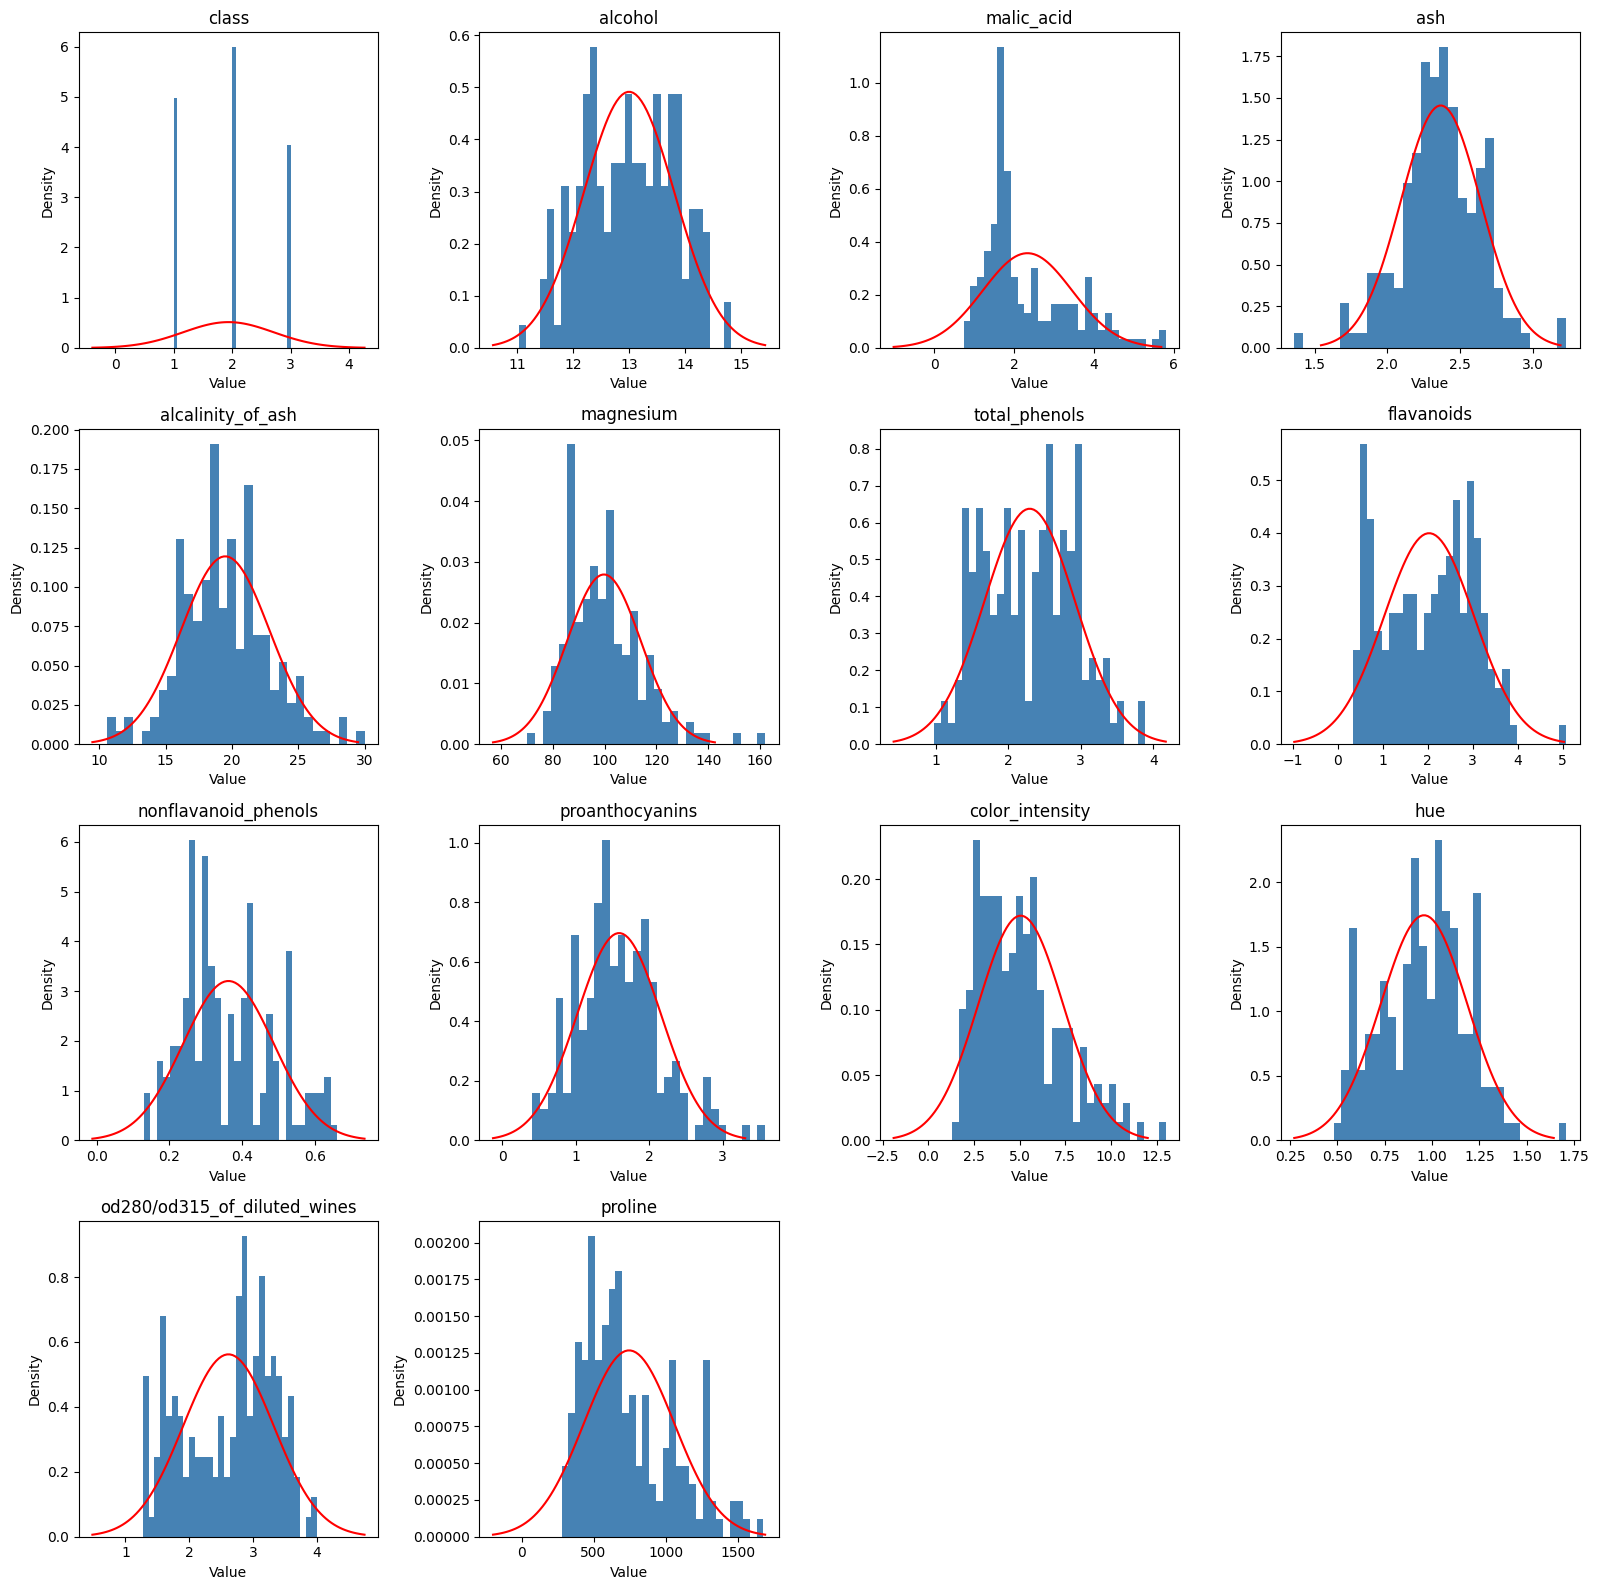

In [6]:
# Create a 4x4 grid of subplots with a fixed size of 16x16 inches
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 16))

# Loop through each column in the dataset
for i, column in enumerate(df_wine.columns):
    # Get the current axis object for this subplot
    ax = axes[i//4, i%4]
    
    # Plot a histogram of the current column's values with 30 bins and steelblue color
    # Set the density argument to True to normalize the histogram
    ax.hist(df_wine[column], bins=30, color='steelblue', density=True)
    
    # Set the title, x-axis label, and y-axis label for the subplot
    ax.set_title(column)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    
    # Calculate the mean and standard deviation of the current column's values
    mu, sigma = df_wine[column].mean(), df_wine[column].std()
    
    # Generate 100 equally spaced values between 3 standard deviations below and above the mean
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
    
    # Plot the normal distribution curve using the calculated mean and standard deviation
    # Set the curve color to red
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red')
    
# Loop through the remaining subplots and remove them from the plot
for j in range(i+1, 4*4):
    axes.flatten()[j].axis('off')    

# Adjust the spacing between the subplots and display the plot
plt.tight_layout()
plt.show()


##### Box Plot
If you're searching for a way to extract valuable insights from your data analysis, then plotting box plots of the independent features is a fantastic solution. These plots offer a wealth of information about the distribution of each feature, enabling you to detect any potential outliers or anomalies that could throw off your analysis or modeling efforts. 

What's great about box plots is that they provide a quick snapshot of several critical pieces of data all at once. For example, you can quickly identify the median (the middle value) and the interquartile range (the range between the 25th and 75th percentiles). Additionally, the whiskers (the lines extending from the box that indicate the range of the data) provide an idea of how spread out your data is. Finally, any outliers (points that fall outside the whiskers) are easily identifiable, allowing you to address them quickly and accurately.

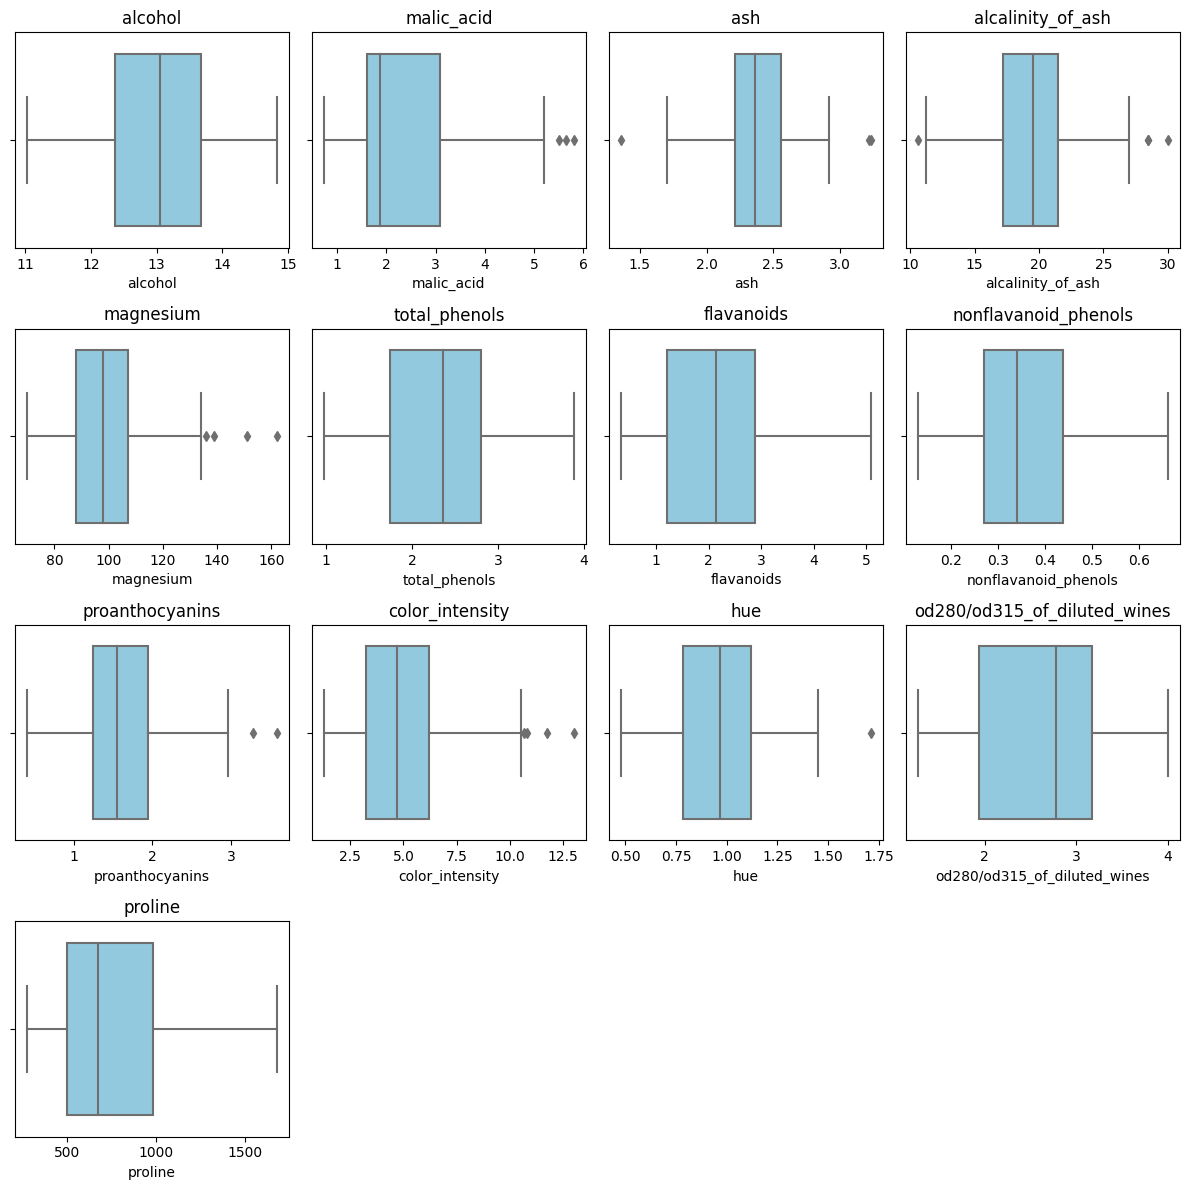

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#Create 4x4 subplots
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

#Loop through each feature and plot a boxplot in a subplot
for i, feature in enumerate(df_wine.columns[1:]):
    row = i // 4
    col = i % 4
    sns.boxplot(x=feature, data=df_wine, ax=axs[row, col], color='skyblue')
    axs[row, col].set_title(feature)

#Remove unused subplots
for j in range(i+1, 4*4):
    axs.flatten()[j].axis('off')

plt.tight_layout()
plt.show()


##### Data Scale and Ranges

Examining the data ranges and scales in a dataset is crucial in data analysis as it can uncover important insights about the data's characteristics that can affect analysis and modeling. By examining the range of each variable, outliers or extreme values that may be affecting the analysis or modeling can be identified. In addition, examining the data ranges and scales can help in understanding the distribution of the data and identifying potential issues with skewness or outliers. Overall, examining the data ranges and scales can help in choosing appropriate data preprocessing and modeling techniques.

In [8]:
# Loop through each column of the wine dataframe except the first column
for feature in df_wine.columns[1:]:
    # Get the minimum and maximum values for the current feature
    min_val = df_wine[feature].min()
    max_val = df_wine[feature].max()
    # Calculate the range for the current feature
    feature_range = max_val - min_val
    # Print the minimum, maximum, and range for the current feature
    print(f"{feature}: min={min_val}, max={max_val}, range={feature_range}")


alcohol: min=11.03, max=14.83, range=3.8000000000000007
malic_acid: min=0.74, max=5.8, range=5.06
ash: min=1.36, max=3.23, range=1.8699999999999999
alcalinity_of_ash: min=10.6, max=30.0, range=19.4
magnesium: min=70, max=162, range=92
total_phenols: min=0.98, max=3.88, range=2.9
flavanoids: min=0.34, max=5.08, range=4.74
nonflavanoid_phenols: min=0.13, max=0.66, range=0.53
proanthocyanins: min=0.41, max=3.58, range=3.17
color_intensity: min=1.28, max=13.0, range=11.72
hue: min=0.48, max=1.71, range=1.23
od280/od315_of_diluted_wines: min=1.27, max=4.0, range=2.73
proline: min=278, max=1680, range=1402


##### Conclusions of Data Analysis
After thorough analysis, we’ve gained a deeper comprehension of our data. Our dataset boasts 13 numerical features, all of which are complete with no null values. Our target variable, 'Class,' is categorical. However, the class distribution is not uniform, though the imbalance is not overwhelmingly significant. And, to top it all off, we can confidently say that there are no duplicate records in our dataset.



#### Data Sampling

To enable effective data distribution, it is crucial to analyze the impact of increasing data volume on accuracy. With this in mind, we have created 20 sample sizes of 5% increasing data to conduct a thorough analysis. This approach allows us to understand how data volume affects the accuracy of our analysis, and it also enables us to identify potential trends or patterns that may emerge as data volume increases. 

In [9]:
# Data subsets object (keys are the sample size percentages 5, 10, 15..)

wine_data_subsets:dict[int, pd.DataFrame] = {}

# Save the 10 subsets of the shuffled dataset to a list
for i in range(10, 105, 5):

    # Use the sample method to select increments of 10% of the overall data
    wine_data_shuff = df_wine.sample(frac=i/100, random_state=15).reset_index(drop=True)

    # save the samples to a data frame by percentage 
    wine_data_subsets[int(i)] = pd.DataFrame(wine_data_shuff) 

#### Hold-Out Validation and K-Fold Cross Validation (KNN, GaussianNB, DTC, SVC)
In this experiment, we will use four different algorithms to create models and compare the accuracy of two methods: "hold-out validation" and "k-fold cross-validation." 

The "hold-out validation" method is the first technique we will use. In this method, we randomly split the dataset into a training set (75%) and a testing set (25%). The machine learning algorithm is trained on the training set, and then it is tested on the testing set. We repeat this process for each iteration. The second method is "k-fold cross-validation." Here, the dataset is split into 5 k-folds, and each fold is used as the testing set while the other folds are used as the training set. This process is repeated five times, so each part is used as the testing set once. We then repeat this process several times to get an average accuracy score. 

To compare the accuracy of the machine learning algorithms, we create a dictionary that maps the algorithms' names to the algorithms themselves. Additionally, we create two more dictionaries to store the accuracy scores for the hold-out validation and k-fold cross-validation methods. Next, we iterate over 20 different subsets of the wine dataset, increasing the size of the subsets by 5% each time. For each subset, we separate the dataset into the target class and the features. We use each of the four machine learning algorithms to make predictions about the wine quality and store the accuracy scores for each method in the respective dictionaries. 

The code then prints out the accuracy scores for each of the four machine learning algorithms using both hold-out validation and k-fold cross-validation. This allows us to compare the accuracy of the algorithms using both methods and determine which method is more accurate.

In [10]:

CLF_MAP = {
    'knn': KNeighborsClassifier(n_neighbors=3),
    'naive': GaussianNB(),
    'dt': DecisionTreeClassifier(),
    'svc': SVC()
}
CLF_NAME_MAP = {
    'knn': 'K-Nearest Neighbors',
    'naive': 'Gaussian Naive Bayes',
    'dt': 'Decision Tree',
    'svc': 'Support Vector'
}

wine_h_out_scores_map = {
    'knn': [],
    'naive': [],
    'dt': [],
    'svc':[]
}

wine_k_fold_scores_map = {
    'knn': [],
    'naive': [],
    'dt': [],
    'svc':[]
}

# Iterate through 10 subsets of the wine dataset
for i in range(10, 105, 5):

    # Data Frame for current iterations
    wine_df = deepcopy(wine_data_subsets[int(i)])

    y = wine_df.pop('class').values   #target class
    X = wine_df.values 

    #  Hold-Out Validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=15)

    for key, clf in CLF_MAP.items():

        pipe = Pipeline([('scaler', StandardScaler()), (key, clf)])
        # The pipeline can be used as any other estimator
        # and avoids leaking the test set into the train set
        pipe.fit(X_train, y_train)
        hold_accuracy = pipe.score(X_test, y_test)
        wine_h_out_scores_map[key].append(hold_accuracy)

        # Perform 5-fold cross-validation
        k_fold_scores = cross_val_score(pipe, X, y, cv=5)
        wine_k_fold_scores_map[key].append(np.mean(k_fold_scores))
   

pp = PrettyPrinter(width=160, compact=True)

print('Accuracy Scores for Hold-Out: ')
pp.pprint(wine_h_out_scores_map)
print('Accuracy Scores for K-Fold: ')
pp.pprint(wine_k_fold_scores_map)

C:\Users\joelq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:684: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\joelq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:684: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\joelq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:684: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\joelq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:684: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Accuracy Scores for Hold-Out: 
{'dt': [1.0, 0.8571428571428571, 0.6666666666666666, 0.9090909090909091, 0.7857142857142857, 0.875, 0.8888888888888888, 0.9, 0.9130434782608695, 0.88,
        0.9629629629629629, 0.896551724137931, 0.90625, 0.8235294117647058, 0.8611111111111112, 0.9210526315789473, 0.95, 0.9767441860465116,
        0.9333333333333333],
 'knn': [1.0, 1.0, 0.8888888888888888, 1.0, 0.9285714285714286, 1.0, 1.0, 0.95, 0.8695652173913043, 0.84, 1.0, 1.0, 0.96875, 1.0, 0.9166666666666666,
         0.8947368421052632, 0.925, 0.9767441860465116, 0.9555555555555556],
 'naive': [0.8, 0.8571428571428571, 0.7777777777777778, 1.0, 0.9285714285714286, 1.0, 1.0, 0.95, 1.0, 0.92, 0.9629629629629629, 1.0, 0.96875,
           0.9705882352941176, 0.9722222222222222, 0.9473684210526315, 0.975, 1.0, 0.9777777777777777],
 'svc': [1.0, 1.0, 0.8888888888888888, 1.0, 1.0, 1.0, 0.9444444444444444, 0.95, 0.9565217391304348, 1.0, 0.9629629629629629, 1.0, 1.0, 1.0, 0.9722222222222222,
         0.947

#### Statistical Results
The standard deviation and coefficient of variation are statistical measures used to assess the variability and consistency of accuracy scores in machine learning algorithms. These measures can provide important insights into the performance of different classifiers and validation methods. To calculate the standard deviation and coefficient of variation of a set of scores, a function can be defined that takes in the scores and returns these two measures. 

In order to apply this function to multiple classifiers and validation methods, a loop can be created that iterates through a dictionary of classifiers and their names. For each classifier, the loop calculates and prints the standard deviation and coefficient of variation of both hold-out and k-fold scores. 

The hold-out scores are obtained by splitting the data into training and testing sets, fitting the pipeline (which includes data scaling and the classifier), and computing the accuracy score on the testing set. This method provides a single estimate of the accuracy of the classifier on unseen data. However, it can be sensitive to the particular split of the data, and may not be representative of the classifier's true performance. 

The k-fold scores, on the other hand, are obtained by performing 5-fold cross-validation on the entire dataset using the same pipeline and classifier. This method involves splitting the data into 5 equal parts, using 4 of these parts for training and the remaining part for testing, and repeating this process 5 times. This results in 5 accuracy scores, which can be averaged to provide a more robust estimate of the classifier's performance. 

By calculating the standard deviation and coefficient of variation of both hold-out and k-fold scores for each classifier, we can gain a better understanding of the variability and consistency of the classifier's performance across different validation methods


In [11]:
# Define a function to calculate standard deviation and coefficient of variation
def calc_stats(scores):
    std = np.std(scores)
    cv = std / np.mean(scores)
    return std, cv


# Calculate and Print the Standard Deviation for k-fold results
for key, clf in CLF_NAME_MAP.items():
    std_hold_out, cv_hold_out = calc_stats(wine_h_out_scores_map[key])
    print(f"\n{clf} Hold-Out Standard Deviation: ", std_hold_out)
    print(f"{clf} Hold-Out Coefficient of Variation: ", f"{(cv_hold_out*100):.2f}%")
    std_fold, cv_fold = calc_stats(wine_k_fold_scores_map[key])
    print(f"\n{clf} K-Fold Standard Deviation: ", std_fold)
    print(f"{clf} k-fold Coefficient of Variation: " , f"{(cv_fold*100):.2f}%")
    



K-Nearest Neighbors Hold-Out Standard Deviation:  0.050488401602740186
K-Nearest Neighbors Hold-Out Coefficient of Variation:  5.30%

K-Nearest Neighbors K-Fold Standard Deviation:  0.01696779937129421
K-Nearest Neighbors k-fold Coefficient of Variation:  1.78%

Gaussian Naive Bayes Hold-Out Standard Deviation:  0.06484427964670526
Gaussian Naive Bayes Hold-Out Coefficient of Variation:  6.84%

Gaussian Naive Bayes K-Fold Standard Deviation:  0.034277833305281044
Gaussian Naive Bayes k-fold Coefficient of Variation:  3.61%

Decision Tree Hold-Out Standard Deviation:  0.07258541870184565
Decision Tree Hold-Out Coefficient of Variation:  8.16%

Decision Tree K-Fold Standard Deviation:  0.055462000479612354
Decision Tree k-fold Coefficient of Variation:  6.42%

Support Vector Hold-Out Standard Deviation:  0.030115505606364085
Support Vector Hold-Out Coefficient of Variation:  3.07%

Support Vector K-Fold Standard Deviation:  0.01408022435300475
Support Vector k-fold Coefficient of Variat

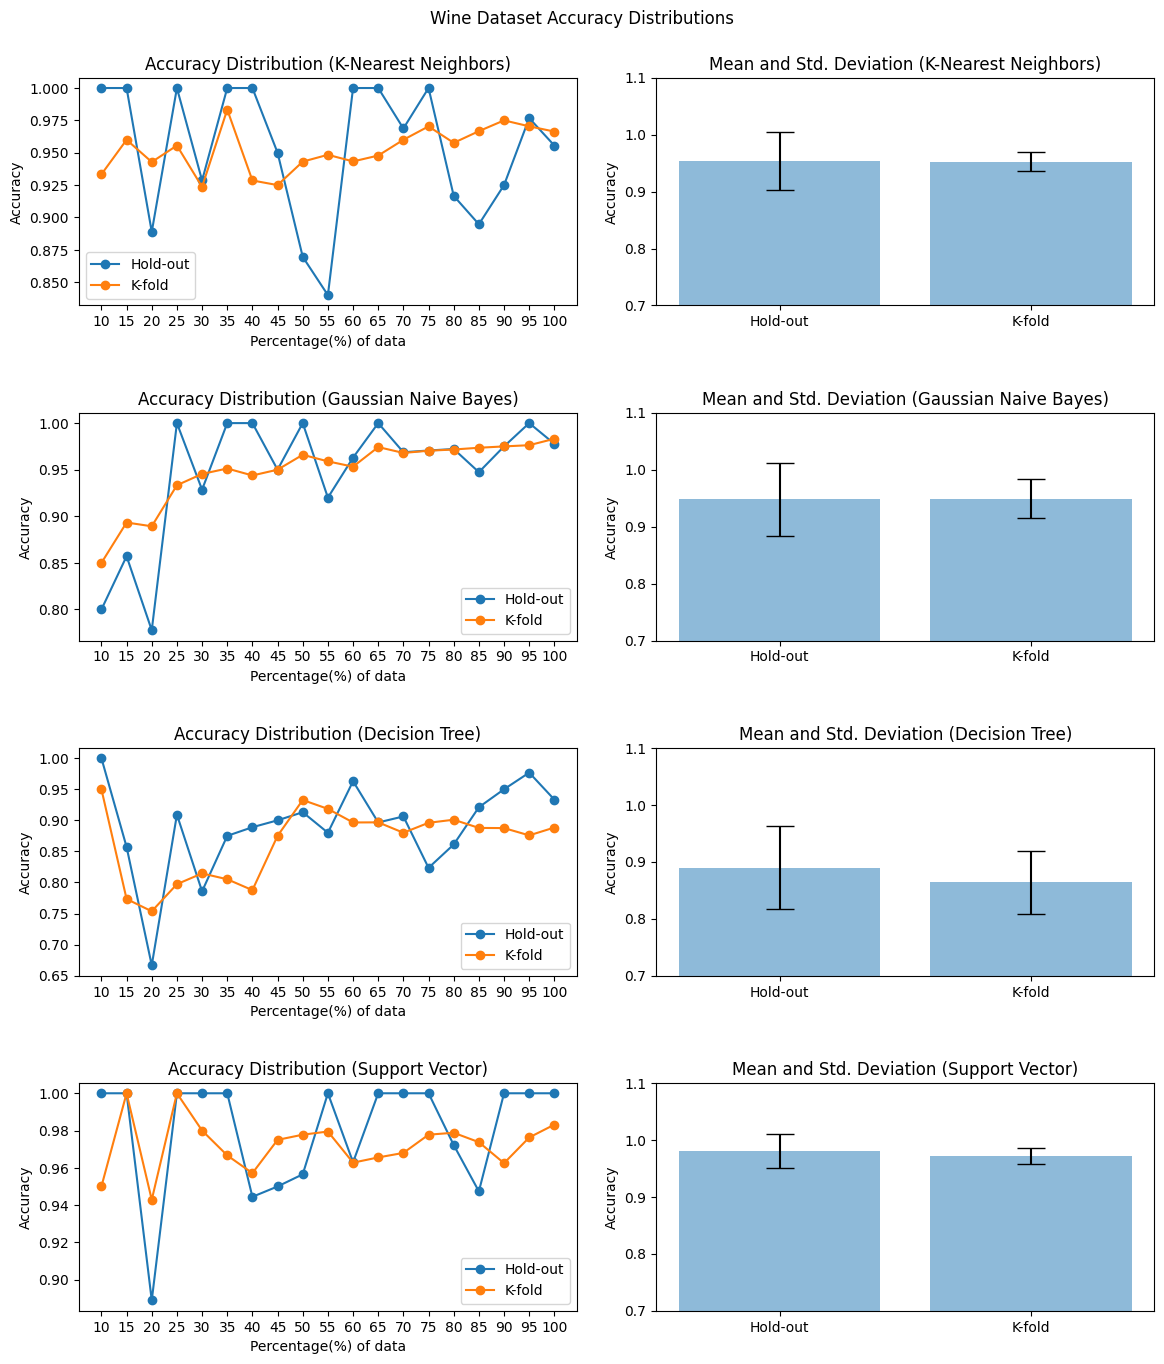

In [12]:
# plot hold-out vs. k-fold scores
models = ['knn', 'naive', 'dt', 'svc']
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
fig.suptitle('Wine Dataset Accuracy Distributions')
iterations = range(10, 105, 5)
for i, model in enumerate(models):
    axs[i, 0].plot(iterations,wine_h_out_scores_map[model],marker='o', label='Hold-out')
    axs[i, 0].plot(iterations,wine_k_fold_scores_map[model],marker='o', label='K-fold')  
    axs[i, 0].set_title(f'Accuracy Distribution ({CLF_NAME_MAP[model]})')
    axs[i, 0].set_ylabel('Accuracy')
    axs[i, 0].set_xlabel("Percentage(%) of data")
    axs[i, 0].set_xticks(range(10, 105, 5))
    axs[i, 0].legend()
    

    # box plot mean and standard deviation for hold-out and k-fold
    hold_out_mean = np.mean(wine_h_out_scores_map[model])
    hold_out_std = np.std(wine_h_out_scores_map[model])
    k_fold_mean = np.mean(wine_k_fold_scores_map[model])
    k_fold_std = np.std(wine_k_fold_scores_map[model])
    axs[i, 1].bar(['Hold-out', 'K-fold'], [hold_out_mean, k_fold_mean], yerr=[hold_out_std, k_fold_std], align='center',  alpha=0.5, ecolor='black', capsize=10)
    axs[i, 1].set_title(f'Mean and Std. Deviation ({CLF_NAME_MAP[model]})')
    axs[i, 1].set_ylabel('Accuracy')
    axs[i, 1].set_ylim(0.7,1.1)

plt.tight_layout(pad=2, h_pad=3)
plt.show()

### Ionosphere Dataset 
The Ionosphere dataset is a machine learning dataset that contains data on radar returns from the ionosphere. The dataset was first published by J. Donato and M. G. A. Figueiredo in 2002 and is widely used in the research community for classification tasks.

The dataset contains 351 observations, each with 34 different attributes. The first 33 attributes are numerical values that represent the strength and angle of the radar returns, while the 34th attribute is a binary class label that indicates whether the radar return was "good" or "bad". A "good" return indicates that the ionosphere is likely to be present, while a "bad" return indicates that there is no ionosphere present.

The numerical attributes are derived from five different radar signals, each of which is represented by seven different measurements. The seven measurements for each signal are:

1. Mean amplitude
2. Standard deviation of amplitude
3. Mean phase
4. Standard deviation of phase
5. Mean angle
6. Standard deviation of angle
7. Sum of correlation coefficients

#### Importing the dataset
The [Ionosphere Dataset](https://archive.ics.uci.edu/ml/datasets/Ionosphere) is downloaded from the UCI Repository. The data is loaded into a pandas dataframe. As the dataframe does not have header columns we add the header values to each column of the dataset and save the dataframe into a CSV file.

In [13]:
# Load the wine dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"

# Add headers to the pandas dataframe
names = ['col_a', 'col_b', 'col_c', 'col_d', 'col_e', 'col_f', 'col_g', 'col_h', 'col_i', 'col_j', 'col_k', 'col_l', 'col_m', 
                                              'col_n', 'col_o', 'col_p', 'col_q', 'col_r', 'col_s', 'col_t', 'col_u', 'col_v', 'col_w', 'col_x', 'col_y', 'col_z',
                                              'col_aa','col_ab' , 'col_ac','col_ad','col_ae','col_af','col_ag','col_ah','class']

# Write the dataframe to a .csv file
df_iono = pd.read_csv(url, names=names)

#df_wine.columns = ['Class','Alcohol', 'Malic acid','Ash', 'Alcalinity of ash','Magnesium', 'Total phenols','Flavanoids', 'Nonflavanoid phenols','Proanthocyanins','Color intensity','Hue','OD280/OD315 of diluted wines','Proline']

# Write the dataframe to a .csv file
df_iono.to_csv('wine.csv', index=False)

#### Data Analysis and Exploration
Let us explore the ionosphere dataset through data analysis and exploration. We'll start by running some exciting functions like .head(), .info(), and .describe() on the Ionosphere Dataset. These functions will reveal details about the dataset such as the various features, data types, and statistical descriptions.

We also want to dive even deeper and discover how the data is split up between the different target classes. By doing so, we'll gain valuable insights that will help us better understand the steps and approaches we need to take to conduct this experiment.

In [14]:
#looking at top 5 data points
df_iono.head()

,col_a,col_b,col_c,col_d,col_e,col_f,col_g,col_h,col_i,col_j,...,col_z,col_aa,col_ab,col_ac,col_ad,col_ae,col_af,col_ag,col_ah,class
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [15]:
df_iono.info()
df_iono.describe()

print("The total number records in each column is:")
print(df_iono.count())
print("\n")

print("Let's check if there are any duplicate records in the dataset: ", df_iono.duplicated().any())
print("\n")

print("Number of duplicate rows: ", df_iono.duplicated().sum())
print("\n")

print("We will drop all the duplicate records from the dataset.")
print("\n")
df_iono = df_iono.drop_duplicates()

print("Number of duplicate rows after deleting duplicates: ", df_iono.duplicated().sum())
print("\n")

print("The total number of null records in the dataset is:")
print(df_iono.isna().sum())
print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 35 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_a   351 non-null    int64  
 1   col_b   351 non-null    int64  
 2   col_c   351 non-null    float64
 3   col_d   351 non-null    float64
 4   col_e   351 non-null    float64
 5   col_f   351 non-null    float64
 6   col_g   351 non-null    float64
 7   col_h   351 non-null    float64
 8   col_i   351 non-null    float64
 9   col_j   351 non-null    float64
 10  col_k   351 non-null    float64
 11  col_l   351 non-null    float64
 12  col_m   351 non-null    float64
 13  col_n   351 non-null    float64
 14  col_o   351 non-null    float64
 15  col_p   351 non-null    float64
 16  col_q   351 non-null    float64
 17  col_r   351 non-null    float64
 18  col_s   351 non-null    float64
 19  col_t   351 non-null    float64
 20  col_u   351 non-null    float64
 21  col_v   351 non-null    float64
 22  co

In [16]:
# The target variable is in a column named 'Class'
class_counts = df_iono['class'].value_counts()
print(class_counts)

g    225
b    125
Name: class, dtype: int64


##### Histogram
We will plot the histogram of all the features in the dataset. Histograms are not just another dry tool for data analysis. They are like a treasure map that can lead you to valuable insights about your data. These visualizations are particularly useful when exploring the distribution of a single variable. They can help you identify potential outliers, skewness, or other anomalies that may affect your analysis or modeling. 

C:\Users\joelq\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_distn_infrastructure.py:2085: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


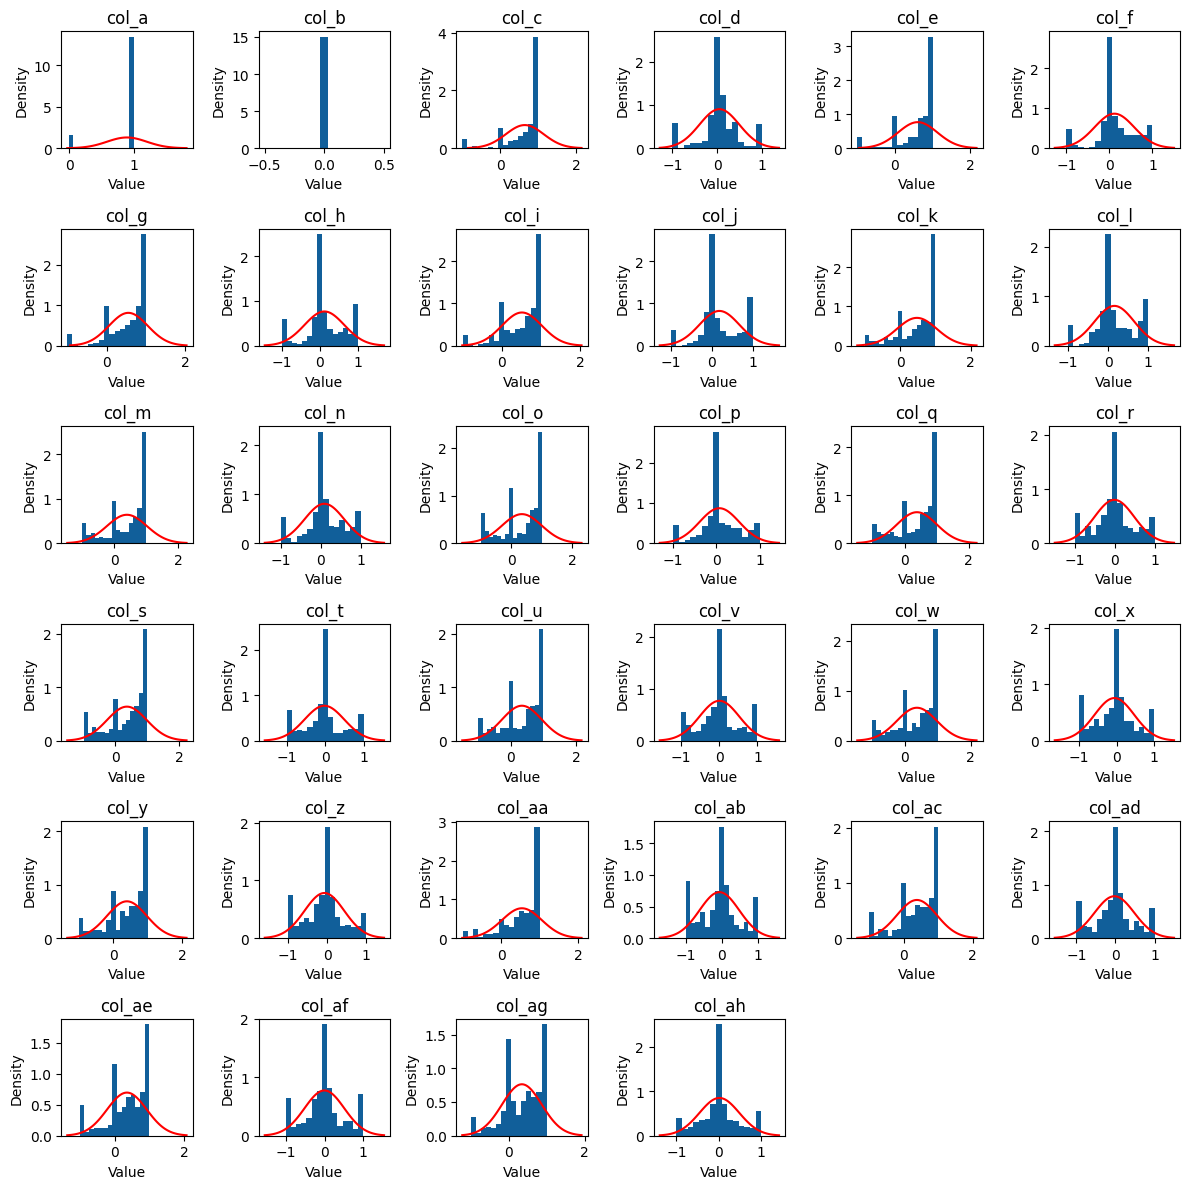

In [17]:
# 6x6 grid of subplots 
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(12, 12))

# Loop through each column in the dataset
for i, column in enumerate(df_iono.columns):
    
    if column == 'class':
        continue
    
    # Get the current axis object for this subplot
    ax = axes[i//6, i%6]

    # Histogram of the current column's value
    # Set the density argument to True to normalize the histogram
    ax.hist(df_iono[column], bins=15, color='#115f9a', density=True) 
    ax.set_title(column)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    
    # Calculate the mean and standard deviation of the current column's values
    mu, sigma = df_iono[column].mean(), df_iono[column].std()
    
    # Generate 100 equally spaced values between 3 standard deviations below and above the mean
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
    
    # Plot the normal distribution curve using the calculated mean and standard deviation
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red')
    
# Remove the excess plots
for j in range(i, 6*6):
    axes.flatten()[j].axis('off')    

# Set the plot layout
plt.tight_layout()
plt.show()


##### Box Plot
If you're searching for a way to extract valuable insights from your data analysis, then plotting box plots of the independent features is a fantastic solution. These plots offer a wealth of information about the distribution of each feature, enabling you to detect any potential outliers or anomalies that could throw off your analysis or modeling efforts. 

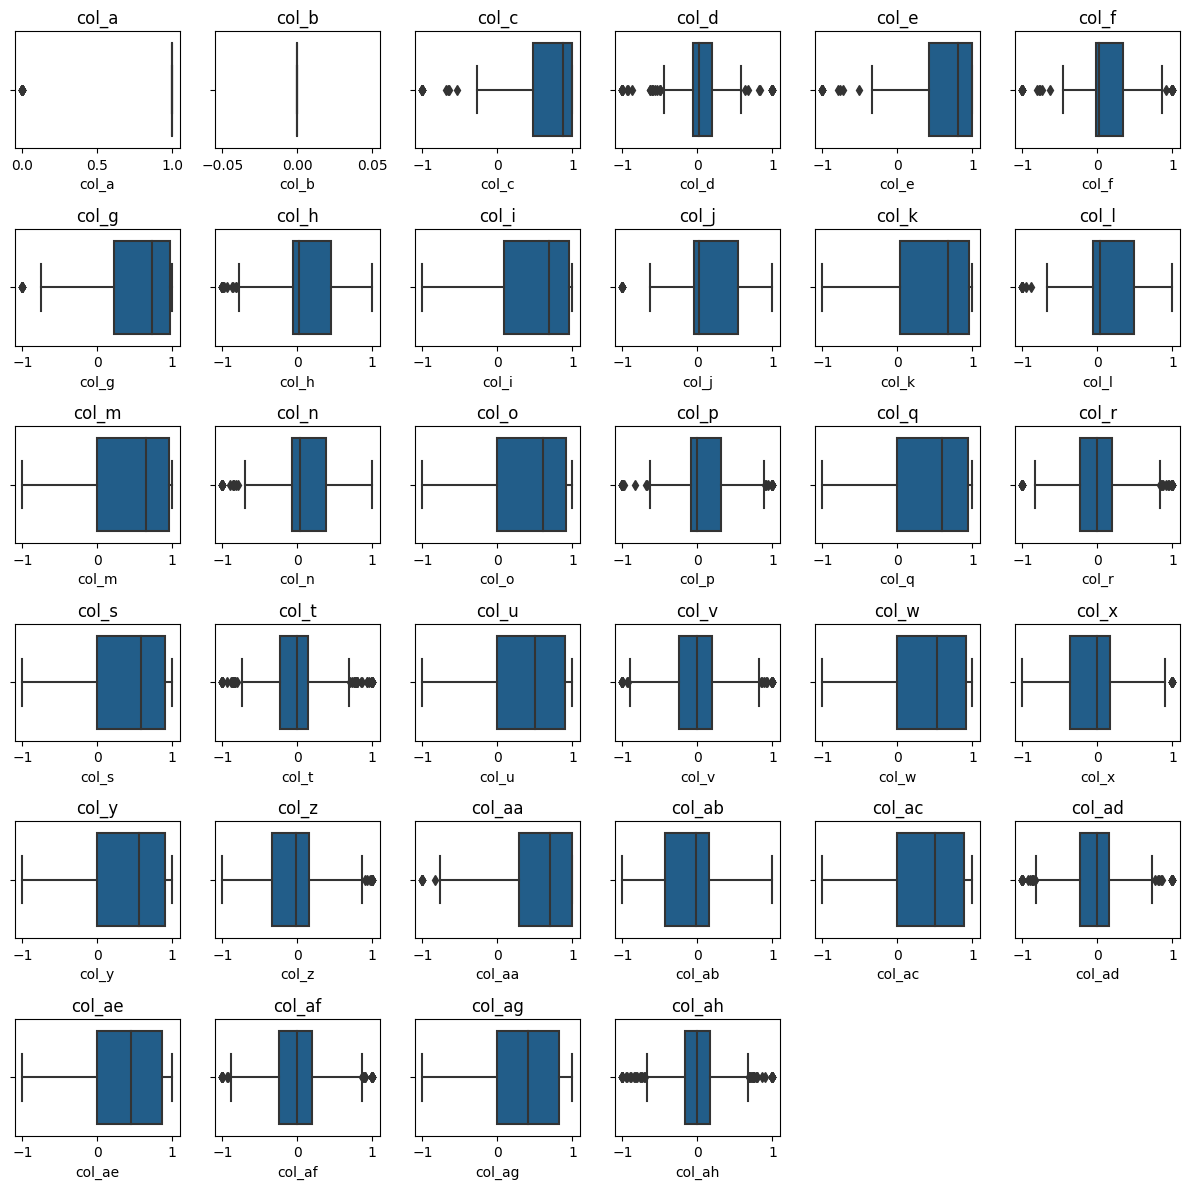

In [18]:
# 6x6 grid of subplots
fig, axs = plt.subplots(6, 6, figsize=(12, 12))

#Loop through each feature and plot a boxplot in a subplot
for i, feature in enumerate(df_iono.columns):
    if feature == 'class':
        continue
    row = i // 6
    col = i % 6
    sns.boxplot(x=feature, data=df_iono, ax=axs[row, col], color='#115f9a')
    axs[row, col].set_title(feature)

#Remove unused subplots
for j in range(i, 6*6):
    axs.flatten()[j].axis('off')

plt.tight_layout()
plt.show()


##### Data Scale and Ranges

Examining the data ranges and scales in a dataset is crucial in data analysis as it can uncover important insights about the data's characteristics that can affect analysis and modeling. By examining the range of each variable, outliers or extreme values that may be affecting the analysis or modeling can be identified. In addition, examining the data ranges and scales can help in understanding the distribution of the data and identifying potential issues with skewness or outliers. Overall, examining the data ranges and scales can help in choosing appropriate data preprocessing and modeling techniques.

In [19]:
# Loop through the independent features
for feature in df_iono.columns[:-1]:
    # Get the minimum and maximum values for the current feature
    min_val = df_iono[feature].min()
    max_val = df_iono[feature].max()
    # Calculate the range for the current feature
    feature_range = max_val - min_val
    # Print the minimum, maximum, and range for the current feature
    print(f"{feature}: min = {min_val}, max = {max_val}, range = {feature_range}")

col_a: min = 0, max = 1, range = 1
col_b: min = 0, max = 0, range = 0
col_c: min = -1.0, max = 1.0, range = 2.0
col_d: min = -1.0, max = 1.0, range = 2.0
col_e: min = -1.0, max = 1.0, range = 2.0
col_f: min = -1.0, max = 1.0, range = 2.0
col_g: min = -1.0, max = 1.0, range = 2.0
col_h: min = -1.0, max = 1.0, range = 2.0
col_i: min = -1.0, max = 1.0, range = 2.0
col_j: min = -1.0, max = 1.0, range = 2.0
col_k: min = -1.0, max = 1.0, range = 2.0
col_l: min = -1.0, max = 1.0, range = 2.0
col_m: min = -1.0, max = 1.0, range = 2.0
col_n: min = -1.0, max = 1.0, range = 2.0
col_o: min = -1.0, max = 1.0, range = 2.0
col_p: min = -1.0, max = 1.0, range = 2.0
col_q: min = -1.0, max = 1.0, range = 2.0
col_r: min = -1.0, max = 1.0, range = 2.0
col_s: min = -1.0, max = 1.0, range = 2.0
col_t: min = -1.0, max = 1.0, range = 2.0
col_u: min = -1.0, max = 1.0, range = 2.0
col_v: min = -1.0, max = 1.0, range = 2.0
col_w: min = -1.0, max = 1.0, range = 2.0
col_x: min = -1.0, max = 1.0, range = 2.0
col_y:

##### Conclusions of Data Analysis
After thorough analysis, we’ve gained a deeper comprehension of our data. Our dataset boasts 33 numerical features, all of which are complete with no null values. Our target variable, 'Class,' is categorical. However, the class distribution is not uniform, though the imbalance is not overwhelmingly significant. 

We have just one duplicate record which we have deleted. Furthermore as data in the columns is are of almost the same ranges we will not normalise the data.

#### Data Sampling

To enable effective data distribution, it is crucial to analyze the impact of increasing data volume on accuracy. With this in mind, we have created 20 sample sizes of 5% increasing data to conduct a thorough analysis. This approach allows us to understand how data volume affects the accuracy of our analysis, and it also enables us to identify potential trends or patterns that may emerge as data volume increases. 

In [20]:
# Data subsets object (keys are the sample size percentages 5, 10, 15..)

iono_data_subsets:dict[int, pd.DataFrame] = {}

# Save the 10 subsets of the shuffled dataset to a list
for i in range(10, 105, 5):

    # Use the sample method to select increments of 10% of the overall data
    iono_data_shuff = df_iono.sample(frac=i/100, random_state=15).reset_index(drop=True)

    # save the samples to a data frame by percentage 
    iono_data_subsets[int(i)] = pd.DataFrame(iono_data_shuff) 


#### Hold-Out Validation and K-Fold Cross Validation (KNN, GaussianNB, DTC, SVC)
In this experiment, we will use four different algorithms to create models and compare the accuracy of two methods: "hold-out validation" and "k-fold cross-validation." 

The "hold-out validation" method is the first technique we will use. In this method, we randomly split the dataset into a training set (75%) and a testing set (25%). The machine learning algorithm is trained on the training set, and then it is tested on the testing set. We repeat this process for each iteration. The second method is "k-fold cross-validation." Here, the dataset is split into 5 k-folds, and each fold is used as the testing set while the other folds are used as the training set. This process is repeated five times, so each part is used as the testing set once. We then repeat this process several times to get an average accuracy score. 

To compare the accuracy of the machine learning algorithms, we create a dictionary that maps the algorithms' names to the algorithms themselves. Additionally, we create two more dictionaries to store the accuracy scores for the hold-out validation and k-fold cross-validation methods. Next, we iterate over 20 different subsets of the wine dataset, increasing the size of the subsets by 5% each time. For each subset, we separate the dataset into the target class and the features. We use each of the four machine learning algorithms to make predictions about the wine quality and store the accuracy scores for each method in the respective dictionaries. 

The code then prints out the accuracy scores for each of the four machine learning algorithms using both hold-out validation and k-fold cross-validation. This allows us to compare the accuracy of the algorithms using both methods and determine which method is more accurate.

In [21]:

CLF_MAP = {
    'knn': KNeighborsClassifier(n_neighbors=3),
    'naive': GaussianNB(),
    'dt': DecisionTreeClassifier(),
    'svc': SVC()
}
CLF_NAME_MAP = {
    'knn': 'K-Nearest Neighbors',
    'naive': 'Gaussian Naive Bayes',
    'dt': 'Decision Tree',
    'svc': 'Support Vector'
}

iono_h_out_scores_map = {
    'knn': [],
    'naive': [],
    'dt': [],
    'svc':[]
}

iono_k_fold_scores_map = {
    'knn': [],
    'naive': [],
    'dt': [],
    'svc':[]
}

# Iterate through 10 subsets of the wine dataset
for i in range(10, 105, 5):

    # Data Frame for current iterations
    iono_df = deepcopy(iono_data_subsets[int(i)])

    y = iono_df.pop('class').values   #target class
    X = iono_df.values 

    #  Hold-Out Validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=15)

    for key, clf in CLF_MAP.items():

        pipe = Pipeline([ (key, clf)])
        # The pipeline can be used as any other estimator
        # and avoids leaking the test set into the train set
        pipe.fit(X_train, y_train)
        hold_accuracy = pipe.score(X_test, y_test)
        iono_h_out_scores_map[key].append(hold_accuracy)

        # Perform 5-fold cross-validation
        k_fold_scores = cross_val_score(pipe, X, y, cv=5)
        iono_k_fold_scores_map[key].append(np.mean(k_fold_scores))
   

pp = PrettyPrinter(width=160, compact=True)

print('Accuracy Scores for Hold-Out: ')
pp.pprint(iono_h_out_scores_map)
print('Accuracy Scores for K-Fold: ')
pp.pprint(iono_k_fold_scores_map)

Accuracy Scores for Hold-Out: 
{'dt': [0.6666666666666666, 0.9230769230769231, 0.9444444444444444, 0.8636363636363636, 0.9259259259259259, 0.9032258064516129, 0.9428571428571428, 0.85,
        0.9090909090909091, 0.8775510204081632, 0.9056603773584906, 0.9122807017543859, 0.9032258064516129, 0.8787878787878788, 0.8142857142857143,
        0.8533333333333334, 0.8860759493670886, 0.8192771084337349, 0.8863636363636364],
 'knn': [0.5555555555555556, 0.8461538461538461, 0.8333333333333334, 0.8636363636363636, 0.6666666666666666, 0.8387096774193549, 0.8571428571428571, 0.85,
         0.8181818181818182, 0.8367346938775511, 0.7924528301886793, 0.7894736842105263, 0.7741935483870968, 0.7272727272727273, 0.7571428571428571, 0.84,
         0.8227848101265823, 0.8433734939759037, 0.7954545454545454],
 'naive': [0.6666666666666666, 0.9230769230769231, 0.8888888888888888, 0.8636363636363636, 0.8888888888888888, 0.8709677419354839, 0.8, 0.825,
           0.8636363636363636, 0.8367346938775511, 0.86

#### Statistical Results
The standard deviation and coefficient of variation are statistical measures used to assess the variability and consistency of accuracy scores in machine learning algorithms. These measures can provide important insights into the performance of different classifiers and validation methods. To calculate the standard deviation and coefficient of variation of a set of scores, a function can be defined that takes in the scores and returns these two measures. 

In order to apply this function to multiple classifiers and validation methods, a loop can be created that iterates through a dictionary of classifiers and their names. For each classifier, the loop calculates and prints the standard deviation and coefficient of variation of both hold-out and k-fold scores. 

The hold-out scores are obtained by splitting the data into training and testing sets, fitting the pipeline (which includes data scaling and the classifier), and computing the accuracy score on the testing set. This method provides a single estimate of the accuracy of the classifier on unseen data. However, it can be sensitive to the particular split of the data, and may not be representative of the classifier's true performance. 

The k-fold scores, on the other hand, are obtained by performing 5-fold cross-validation on the entire dataset using the same pipeline and classifier. This method involves splitting the data into 5 equal parts, using 4 of these parts for training and the remaining part for testing, and repeating this process 5 times. This results in 5 accuracy scores, which can be averaged to provide a more robust estimate of the classifier's performance. 

By calculating the standard deviation and coefficient of variation of both hold-out and k-fold scores for each classifier, we can gain a better understanding of the variability and consistency of the classifier's performance across different validation methods


In [22]:
# Define a function to calculate standard deviation and coefficient of variation
def calc_stats(scores):
    std = np.std(scores)
    cv = std / np.mean(scores)
    return std, cv


# Calculate and Print the Standard Deviation for k-fold results
for key, clf in CLF_NAME_MAP.items():
    std_hold_out, cv_hold_out = calc_stats(iono_h_out_scores_map[key])
    print(f"\n{clf} Hold-Out Standard Deviation: ", std_hold_out)
    print(f"{clf} Hold-Out Coefficient of Variation: ", f"{(cv_hold_out*100):.2f}%")
    std_fold, cv_fold = calc_stats(iono_k_fold_scores_map[key])
    print(f"\n{clf} K-Fold Standard Deviation: ", std_fold)
    print(f"{clf} k-fold Coefficient of Variation: " , f"{(cv_fold*100):.2f}%")
    



K-Nearest Neighbors Hold-Out Standard Deviation:  0.07444650829243342
K-Nearest Neighbors Hold-Out Coefficient of Variation:  9.36%

K-Nearest Neighbors K-Fold Standard Deviation:  0.030736760793289037
K-Nearest Neighbors k-fold Coefficient of Variation:  3.74%

Gaussian Naive Bayes Hold-Out Standard Deviation:  0.05386926467633598
Gaussian Naive Bayes Hold-Out Coefficient of Variation:  6.32%

Gaussian Naive Bayes K-Fold Standard Deviation:  0.019806215155954706
Gaussian Naive Bayes k-fold Coefficient of Variation:  2.23%

Decision Tree Hold-Out Standard Deviation:  0.061138442464839855
Decision Tree Hold-Out Coefficient of Variation:  6.97%

Decision Tree K-Fold Standard Deviation:  0.02102548911577461
Decision Tree k-fold Coefficient of Variation:  2.37%

Support Vector Hold-Out Standard Deviation:  0.09180358388132892
Support Vector Hold-Out Coefficient of Variation:  10.01%

Support Vector K-Fold Standard Deviation:  0.029219468041876803
Support Vector k-fold Coefficient of Varia

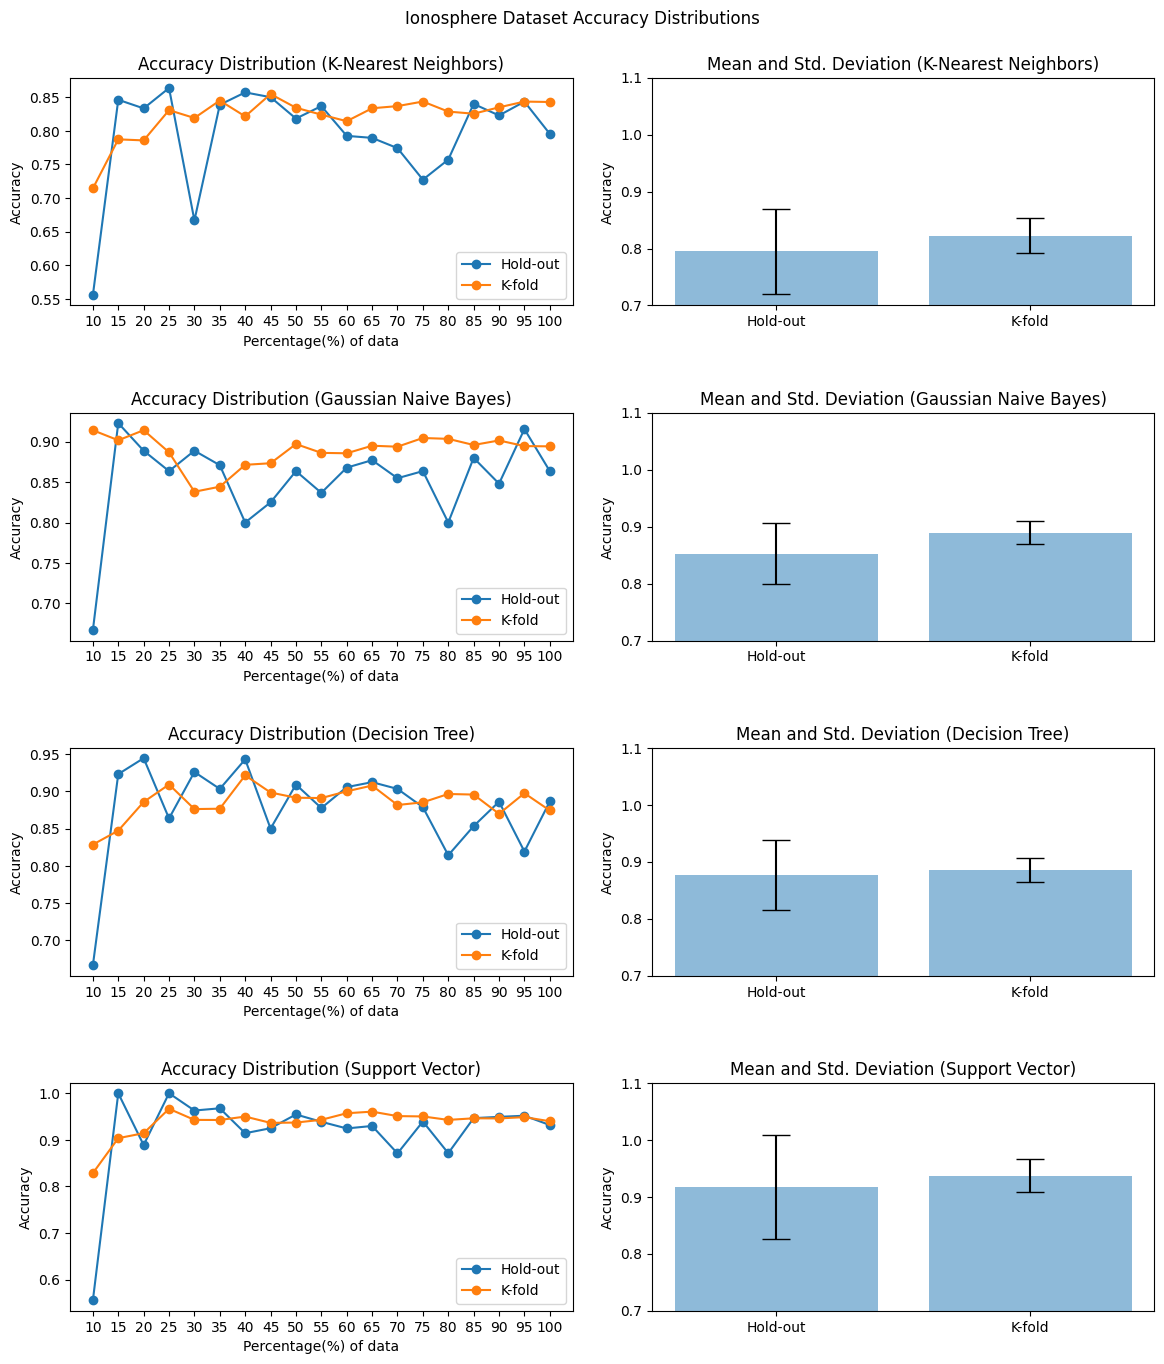

In [23]:
# plot hold-out vs. k-fold scores
models = ['knn', 'naive', 'dt', 'svc']
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
fig.suptitle('Ionosphere Dataset Accuracy Distributions')
iterations = range(10, 105, 5)
for i, model in enumerate(models):
    axs[i, 0].plot(iterations,iono_h_out_scores_map[model],marker='o', label='Hold-out')
    axs[i, 0].plot(iterations,iono_k_fold_scores_map[model],marker='o', label='K-fold')  
    axs[i, 0].set_title(f'Accuracy Distribution ({CLF_NAME_MAP[model]})')
    axs[i, 0].set_ylabel('Accuracy')
    axs[i, 0].set_xlabel("Percentage(%) of data")
    axs[i, 0].set_xticks(range(10, 105, 5))
    axs[i, 0].legend()
    

    # box plot mean and standard deviation for hold-out and k-fold
    hold_out_mean = np.mean(iono_h_out_scores_map[model])
    hold_out_std = np.std(iono_h_out_scores_map[model])
    k_fold_mean = np.mean(iono_k_fold_scores_map[model])
    k_fold_std = np.std(iono_k_fold_scores_map[model])
    axs[i, 1].bar(['Hold-out', 'K-fold'], [hold_out_mean, k_fold_mean], yerr=[hold_out_std, k_fold_std], align='center',  alpha=0.5, ecolor='black', capsize=10)
    axs[i, 1].set_title(f'Mean and Std. Deviation ({CLF_NAME_MAP[model]})')
    axs[i, 1].set_ylabel('Accuracy')
    axs[i, 1].set_ylim(0.7,1.1)

plt.tight_layout(pad=2, h_pad=3)
plt.show()

### Seeds Dataset 
The Seeds dataset is a machine learning dataset that contains data on three different varieties of wheat seeds. The dataset was first published by M. Charytanowicz et al. in 2010 and is widely used in the research community for classification and clustering tasks.

The dataset contains measurements of seven different attributes of each seed. These attributes are:

1. Area
2. Perimeter
3. Compactness
4. Length of kernel
5. Width of kernel
6. Asymmetry coefficient
7. Length of kernel groove

For each attribute, there are three different measures: the minimum, maximum, and mean values. This gives a total of 21 features for each seed.

In addition to the attribute measurements, each seed is also labeled with its variety. There are three different varieties of seeds in the dataset: Kama, Rosa, and Canadian. There are a total of 210 seeds in the dataset, with 70 seeds for each variety.

#### Importing the dataset
The [Seeds Dataset](http://archive.ics.uci.edu/ml/datasets/seeds) is downloaded from the UCI Repository. The data is loaded into a pandas dataframe. As the dataframe does not have header columns we add the header values to each column of the dataset and save the dataframe into a CSV file.

In [24]:
# Load the Seeds dataset into a pandas dataframe
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
column_names = ['area', 'perimeter', 'compactness', 'length_kernel', 'width_kernel', 'asymmetry_coeff', 'length_kernel_groove', 'variety']
df_seeds = pd.read_csv(url, header=None, names=column_names, delim_whitespace=True)

#### Data Analysis and Exploration
Let us explore the seeds dataset through data analysis and exploration. We'll start by running some exciting functions like .head(), .info(), and .describe() on the Ionosphere Dataset. These functions will reveal details about the dataset such as the various features, data types, and statistical descriptions.

We also want to dive even deeper and discover how the data is split up between the different target classes. By doing so, we'll gain valuable insights that will help us better understand the steps and approaches we need to take to conduct this experiment.

In [25]:
#looking at top 5 data points
df_seeds.head()

,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coeff,length_kernel_groove,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [26]:
df_seeds.info()
df_seeds.describe()

print("The total number records in each column is:")
print(df_seeds.count())
print("\n")

print("Let's check if there are any duplicate records in the dataset: ", df_seeds.duplicated().any())
print("\n")

print("The total number of null records in the dataset is:")
print(df_seeds.isna().sum())
print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  210 non-null    float64
 1   perimeter             210 non-null    float64
 2   compactness           210 non-null    float64
 3   length_kernel         210 non-null    float64
 4   width_kernel          210 non-null    float64
 5   asymmetry_coeff       210 non-null    float64
 6   length_kernel_groove  210 non-null    float64
 7   variety               210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.2 KB
The total number records in each column is:
area                    210
perimeter               210
compactness             210
length_kernel           210
width_kernel            210
asymmetry_coeff         210
length_kernel_groove    210
variety                 210
dtype: int64


Let's check if there are any duplicate records in th

In [27]:
# The target variable is in a column named 'variety'
class_counts = df_seeds['variety'].value_counts()
print(class_counts)

1    70
2    70
3    70
Name: variety, dtype: int64


##### Histogram
We will plot the histogram of all the features in the dataset. Histograms are not just another dry tool for data analysis. They are like a treasure map that can lead you to valuable insights about your data. These visualizations are particularly useful when exploring the distribution of a single variable. They can help you identify potential outliers, skewness, or other anomalies that may affect your analysis or modeling. 

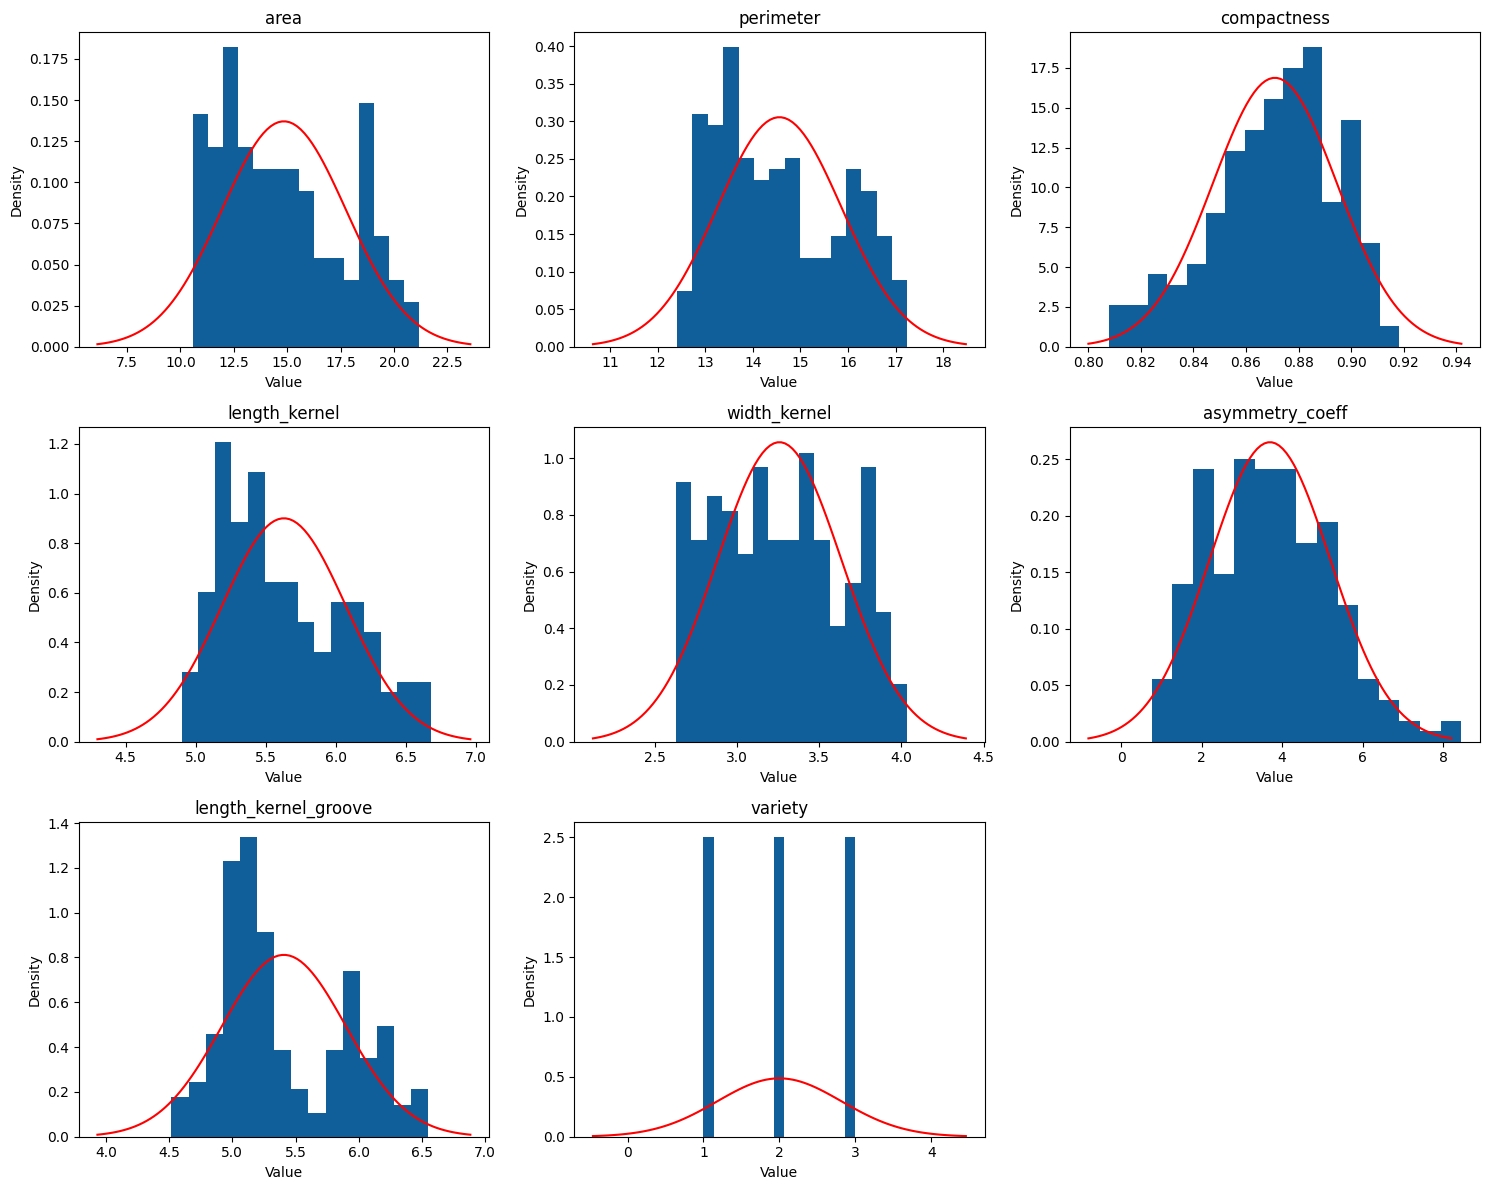

In [28]:
# 3x3 grid of subplots 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Loop through each column in the dataset
for i, column in enumerate(df_seeds.columns):
    
    # Get the current axis object for this subplot
    ax = axes[i//3, i%3]

    # Histogram of the current column's value
    # Set the density argument to True to normalize the histogram
    ax.hist(df_seeds[column], bins=15, color='#115f9a', density=True) 
    ax.set_title(column)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    
    # Calculate the mean and standard deviation of the current column's values
    mu, sigma = df_seeds[column].mean(), df_seeds[column].std()
    
    # Generate 100 equally spaced values between 3 standard deviations below and above the mean
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
    
    # Plot the normal distribution curve using the calculated mean and standard deviation
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red')
    
# Remove the excess plots
for j in range(8, 9):
    axes.flatten()[j].axis('off')    

# Set the plot layout
plt.tight_layout()
plt.show()


##### Box Plot
If you're searching for a way to extract valuable insights from your data analysis, then plotting box plots of the independent features is a fantastic solution. These plots offer a wealth of information about the distribution of each feature, enabling you to detect any potential outliers or anomalies that could throw off your analysis or modeling efforts. 

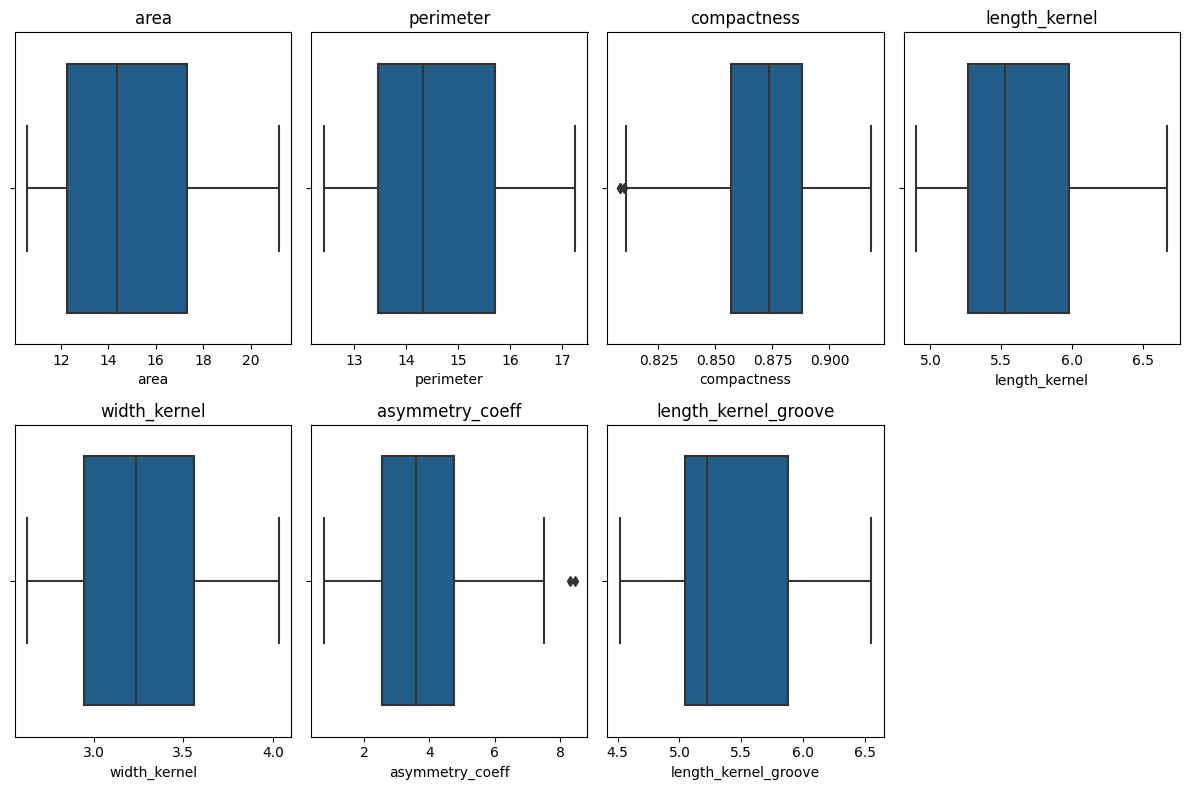

In [29]:
# 4x4 grid of subplots
fig, axs = plt.subplots(2, 4, figsize=(12, 8))

#Loop through each feature and plot a boxplot in a subplot
for i, feature in enumerate(df_seeds.columns[:-1]):
    row = i // 4
    col = i % 4
    sns.boxplot(x=feature, data=df_seeds, ax=axs[row, col], color='#115f9a')
    axs[row, col].set_title(feature)

#Remove unused subplots
for j in range(i+1, 4*2):
    axs.flatten()[j].axis('off')

plt.tight_layout()
plt.show()


##### Data Scale and Ranges

Examining the data ranges and scales in a dataset is crucial in data analysis as it can uncover important insights about the data's characteristics that can affect analysis and modeling. By examining the range of each variable, outliers or extreme values that may be affecting the analysis or modeling can be identified. In addition, examining the data ranges and scales can help in understanding the distribution of the data and identifying potential issues with skewness or outliers. Overall, examining the data ranges and scales can help in choosing appropriate data preprocessing and modeling techniques.

In [30]:
# Loop through the independent features
for feature in df_seeds.columns[:-1]:
    # Get the minimum and maximum values for the current feature
    min_val = df_seeds[feature].min()
    max_val = df_seeds[feature].max()
    # Calculate the range for the current feature
    feature_range = max_val - min_val
    # Print the minimum, maximum, and range for the current feature
    print(f"{feature}: min = {min_val}, max = {max_val}, range = {feature_range}")

area: min = 10.59, max = 21.18, range = 10.59
perimeter: min = 12.41, max = 17.25, range = 4.84
compactness: min = 0.8081, max = 0.9183, range = 0.11019999999999996
length_kernel: min = 4.899, max = 6.675, range = 1.7759999999999998
width_kernel: min = 2.63, max = 4.033, range = 1.4030000000000005
asymmetry_coeff: min = 0.7651, max = 8.456, range = 7.690899999999999
length_kernel_groove: min = 4.519, max = 6.55, range = 2.0309999999999997


##### Conclusions of Data Analysis
After thorough analysis, we’ve gained a deeper comprehension of our data. Our dataset has 7 numerical features, all of which are complete with no null values. Our target variable, 'variety,' is categorical. The target class variety is equally distributed across all the records.And, to top it all off, we can confidently say that there are no duplicate records in our dataset. As the ranges of the features are different we will normalise the data before running the models. 


#### Data Sampling

To enable effective data distribution, it is crucial to analyze the impact of increasing data volume on accuracy. With this in mind, we have created 20 sample sizes of 5% increasing data to conduct a thorough analysis. This approach allows us to understand how data volume affects the accuracy of our analysis, and it also enables us to identify potential trends or patterns that may emerge as data volume increases. 

In [31]:
# Seeds Data subsets

seeds_data_subsets:dict[int, pd.DataFrame] = {}

# Save the 10 subsets of the shuffled dataset to a list
for i in range(10, 105, 5):

    # Use the sample method to select increments of 10% of the overall data
    seeds_data_shuff = df_seeds.sample(frac=i/100, random_state=15).reset_index(drop=True)

    # save the samples to a data frame by percentage 
    seeds_data_subsets[int(i)] = pd.DataFrame(seeds_data_shuff) 


#### Hold-Out Validation and K-Fold Cross Validation (KNN, GaussianNB, DTC, SVC)
In this experiment, we will use four different algorithms to create models and compare the accuracy of two methods: "hold-out validation" and "k-fold cross-validation." 

The "hold-out validation" method is the first technique we will use. In this method, we randomly split the dataset into a training set (75%) and a testing set (25%). The machine learning algorithm is trained on the training set, and then it is tested on the testing set. We repeat this process for each iteration. The second method is "k-fold cross-validation." Here, the dataset is split into 5 k-folds, and each fold is used as the testing set while the other folds are used as the training set. This process is repeated five times, so each part is used as the testing set once. We then repeat this process several times to get an average accuracy score. 

To compare the accuracy of the machine learning algorithms, we create a dictionary that maps the algorithms' names to the algorithms themselves. Additionally, we create two more dictionaries to store the accuracy scores for the hold-out validation and k-fold cross-validation methods. Next, we iterate over 20 different subsets of the wine dataset, increasing the size of the subsets by 5% each time. For each subset, we separate the dataset into the target class and the features. We use each of the four machine learning algorithms to make predictions about the wine quality and store the accuracy scores for each method in the respective dictionaries. 

The code then prints out the accuracy scores for each of the four machine learning algorithms using both hold-out validation and k-fold cross-validation. This allows us to compare the accuracy of the algorithms using both methods and determine which method is more accurate.

In [32]:

seeds_h_out_scores_map = {
    'knn': [],
    'naive': [],
    'dt': [],
    'svc':[]
}

seeds_k_fold_scores_map = {
    'knn': [],
    'naive': [],
    'dt': [],
    'svc':[]
}

# Iterate through 10 subsets of the seeds dataset
for i in range(10, 105, 5):

    # Data Frame for current iterations
    seeds_df = deepcopy(seeds_data_subsets[int(i)])

    y = seeds_df.pop('variety').values   #target class
    X = seeds_df.values 

    #  Hold-Out Validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=15)

    for key, clf in CLF_MAP.items():

        pipe = Pipeline([('scaler', StandardScaler()), (key, clf)])
        # The pipeline can be used as any other estimator and avoids leaking the test set into the train set
        pipe.fit(X_train, y_train)
        hold_accuracy = pipe.score(X_test, y_test)
        seeds_h_out_scores_map[key].append(hold_accuracy)

        # Perform 5-fold cross-validation
        k_fold_scores = cross_val_score(pipe, X, y, cv=5)
        seeds_k_fold_scores_map[key].append(np.mean(k_fold_scores))
   

pp = PrettyPrinter(width=160, compact=True)

print('Accuracy Scores for Hold-Out: ')
pp.pprint(seeds_h_out_scores_map)
print('Accuracy Scores for K-Fold: ')
pp.pprint(seeds_k_fold_scores_map)

Accuracy Scores for Hold-Out: 
{'dt': [1.0, 0.625, 0.7272727272727273, 0.8461538461538461, 0.875, 1.0, 0.8571428571428571, 0.9166666666666666, 0.8148148148148148, 0.9310344827586207, 0.90625,
        0.9411764705882353, 0.8918918918918919, 0.9, 0.9047619047619048, 0.9111111111111111, 0.9375, 0.92, 0.9433962264150944],
 'knn': [0.8333333333333334, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9166666666666666, 0.8888888888888888, 1.0, 0.9375, 0.9117647058823529, 0.8918918918918919, 0.875,
         0.9047619047619048, 0.8888888888888888, 0.9375, 0.92, 0.9245283018867925],
 'naive': [0.8333333333333334, 1.0, 0.9090909090909091, 1.0, 0.9375, 0.9473684210526315, 0.9523809523809523, 0.9166666666666666, 0.8518518518518519,
           0.896551724137931, 0.875, 0.8823529411764706, 0.8648648648648649, 0.9, 0.8809523809523809, 0.8666666666666667, 0.8958333333333334, 0.92,
           0.8867924528301887],
 'svc': [0.8333333333333334, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9166666666666666, 1.0, 1.0, 0.9375, 0.941176470

#### Statistical Results
The standard deviation and coefficient of variation are statistical measures used to assess the variability and consistency of accuracy scores in machine learning algorithms. These measures can provide important insights into the performance of different classifiers and validation methods. To calculate the standard deviation and coefficient of variation of a set of scores, a function can be defined that takes in the scores and returns these two measures. 

In order to apply this function to multiple classifiers and validation methods, a loop can be created that iterates through a dictionary of classifiers and their names. For each classifier, the loop calculates and prints the standard deviation and coefficient of variation of both hold-out and k-fold scores. 

The hold-out scores are obtained by splitting the data into training and testing sets, fitting the pipeline (which includes data scaling and the classifier), and computing the accuracy score on the testing set. This method provides a single estimate of the accuracy of the classifier on unseen data. However, it can be sensitive to the particular split of the data, and may not be representative of the classifier's true performance. 

The k-fold scores, on the other hand, are obtained by performing 5-fold cross-validation on the entire dataset using the same pipeline and classifier. This method involves splitting the data into 5 equal parts, using 4 of these parts for training and the remaining part for testing, and repeating this process 5 times. This results in 5 accuracy scores, which can be averaged to provide a more robust estimate of the classifier's performance. 

By calculating the standard deviation and coefficient of variation of both hold-out and k-fold scores for each classifier, we can gain a better understanding of the variability and consistency of the classifier's performance across different validation methods


In [33]:
# Define a function to calculate standard deviation and coefficient of variation
def calc_stats(scores):
    std = np.std(scores)
    cv = std / np.mean(scores)
    return std, cv


# Calculate and Print the Standard Deviation for k-fold results
for key, clf in CLF_NAME_MAP.items():
    std_hold_out, cv_hold_out = calc_stats(seeds_h_out_scores_map[key])
    print(f"\n{clf} Hold-Out Standard Deviation: ", std_hold_out)
    print(f"{clf} Hold-Out Coefficient of Variation: ", f"{(cv_hold_out*100):.2f}%")
    std_fold, cv_fold = calc_stats(seeds_k_fold_scores_map[key])
    print(f"\n{clf} K-Fold Standard Deviation: ", std_fold)
    print(f"{clf} k-fold Coefficient of Variation: " , f"{(cv_fold*100):.2f}%")
    



K-Nearest Neighbors Hold-Out Standard Deviation:  0.05207889984845409
K-Nearest Neighbors Hold-Out Coefficient of Variation:  5.55%

K-Nearest Neighbors K-Fold Standard Deviation:  0.017308170479920185
K-Nearest Neighbors k-fold Coefficient of Variation:  1.83%

Gaussian Naive Bayes Hold-Out Standard Deviation:  0.04415426528575027
Gaussian Naive Bayes Hold-Out Coefficient of Variation:  4.87%

Gaussian Naive Bayes K-Fold Standard Deviation:  0.021616862970888478
Gaussian Naive Bayes k-fold Coefficient of Variation:  2.38%

Decision Tree Hold-Out Standard Deviation:  0.08634171224252389
Decision Tree Hold-Out Coefficient of Variation:  9.74%

Decision Tree K-Fold Standard Deviation:  0.05073935023197794
Decision Tree k-fold Coefficient of Variation:  5.68%

Support Vector Hold-Out Standard Deviation:  0.052564653685291146
Support Vector Hold-Out Coefficient of Variation:  5.56%

Support Vector K-Fold Standard Deviation:  0.02449608714221514
Support Vector k-fold Coefficient of Variati

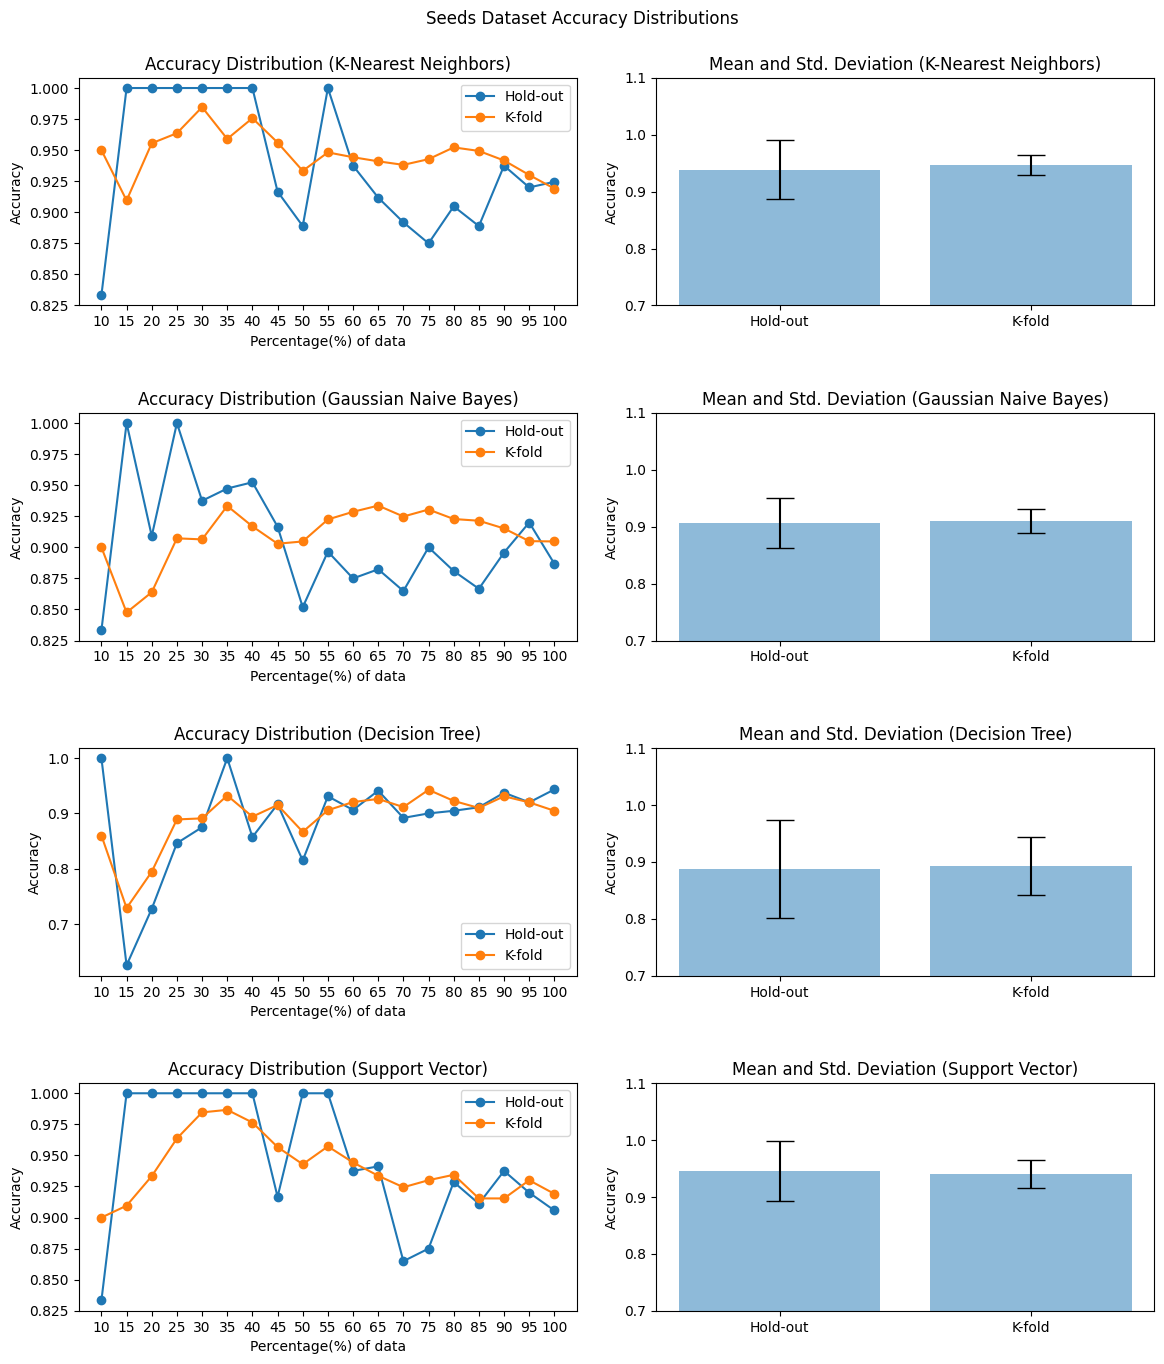

In [34]:
# plot hold-out vs. k-fold scores
models = ['knn', 'naive', 'dt', 'svc']
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
fig.suptitle('Seeds Dataset Accuracy Distributions')
iterations = range(10, 105, 5)
for i, model in enumerate(models):
    axs[i, 0].plot(iterations,seeds_h_out_scores_map[model],marker='o', label='Hold-out')
    axs[i, 0].plot(iterations,seeds_k_fold_scores_map[model],marker='o', label='K-fold')  
    axs[i, 0].set_title(f'Accuracy Distribution ({CLF_NAME_MAP[model]})')
    axs[i, 0].set_ylabel('Accuracy')
    axs[i, 0].set_xlabel("Percentage(%) of data")
    axs[i, 0].set_xticks(range(10, 105, 5))
    axs[i, 0].legend()
    

    # box plot mean and standard deviation for hold-out and k-fold
    hold_out_mean = np.mean(seeds_h_out_scores_map[model])
    hold_out_std = np.std(seeds_h_out_scores_map[model])
    k_fold_mean = np.mean(seeds_k_fold_scores_map[model])
    k_fold_std = np.std(seeds_k_fold_scores_map[model])
    axs[i, 1].bar(['Hold-out', 'K-fold'], [hold_out_mean, k_fold_mean], yerr=[hold_out_std, k_fold_std], align='center',  alpha=0.5, ecolor='black', capsize=10)
    axs[i, 1].set_title(f'Mean and Std. Deviation ({CLF_NAME_MAP[model]})')
    axs[i, 1].set_ylabel('Accuracy')
    axs[i, 1].set_ylim(0.7,1.1)

plt.tight_layout(pad=2, h_pad=3)
plt.show()

## Findings and Conclusions of the Experiment

The question of which validation method to use is a common one in machine learning. Validation techniques are essential because they help evaluate the effectiveness of a model in predicting outcomes. The two most commonly used validation methods are hold-out and k-fold cross-validation.

The hold-out validation technique involves splitting the dataset into two parts, one for training the model and the other for testing it. This technique is simple and easy to implement, but it can lead to overfitting or underfitting, particularly when the size of the dataset is small.

In contrast, k-fold cross-validation involves dividing the dataset into k equal parts, using one part for testing the model and the remaining k-1 parts for training. This technique is more reliable than hold-out validation because it provides a more accurate assessment of the model's performance by using all the available data for testing and training.

Comparing the hold-out validation technique with the k-fold cross-validation method, it can be observed that there is a similar trend of accuracies in all classifiers and across all three datasets. The accuracy distributions show that the accuracies were most unreliable when the amount of data was very small, usually less than 50 of the sample data. The shape of the accuracy distribution lines also indicates that hold-out validation resulted in more unpredictable and unstable predictions, as evident by its zig-zag nature, showing sharp increases and decreases as the data subset changed, while k-fold remained relatively stable at larger sample sizes, i.e., greater than 50 samples. 

Statistically speaking, in all twelve model accuracy distributions, k-fold had a lower standard deviation and coefficient of variation, reaffirming the notion that it provides a more stable prediction accuracy. This stability is further visualized by the smaller margin on the box plots. Therefore, it can be concluded that k-fold cross-validation is a more reliable method for evaluating the performance of classifiers than hold-out validation, particularly when dealing with smaller datasets. However, it is important to note that the choice of validation technique ultimately depends on the specific requirements and characteristics of the dataset and the classifiers being used.

It is worth noting that the choice of validation technique depends on the specific requirements and characteristics of the dataset and the classifiers being used. Therefore, researchers should choose the validation technique that best suits their needs.

In conclusion, while both hold-out and k-fold cross-validation techniques have their strengths and weaknesses, the k-fold cross-validation method is a more reliable technique for evaluating the performance of classifiers, particularly when dealing with smaller datasets.